# DS605 — Lab 4: End-to-End Machine Learning Project
# NYC Airbnb Nightly Price Prediction

**Dataset:** Kaggle *New York City Airbnb Open Data* (`AB_NYC_2019.csv`)

This notebook walks through the full end-to-end workflow required for the assignment:

1. **Task 1 — Data Analysis & Preparation**: EDA, cleaning, preprocessing, feature engineering, feature selection
2. **Task 2 — Model Training & Evaluation**: Linear Regression vs. XGBoost, hyperparameter tuning, evaluation, over/underfitting check, saving the pipeline
3. **Task 4 — Final Summary**: key findings, model comparison, and limitations



> **Note:** All cleaning/feature-engineering logic lives in `src/preprocessing.py` and is imported here
> rather than duplicated, so the exact same transformation is used by this notebook, `src/train.py`,
> and the Streamlit app (no train/serve skew).


## 0. Setup & Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

from preprocessing import (
    clean_raw_data,
    get_feature_target,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    ALL_FEATURES,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Task 1 — Data Analysis and Preparation

### 1.1 Load the raw dataset

In [2]:
df_raw = pd.read_csv("../data/AB_NYC_2019.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

### 1.2 Missing values

In [4]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing


reviews_per_month    10052
last_review          10052
host_name               21
name                    16
dtype: int64

`last_review` and `reviews_per_month` are missing for the same ~10,000 rows — these are simply
listings that have never received a review, not random missing data. `name` and `host_name` have a
negligible number of missing values and are not used as model features.

### 1.3 Target variable (`price`) distribution

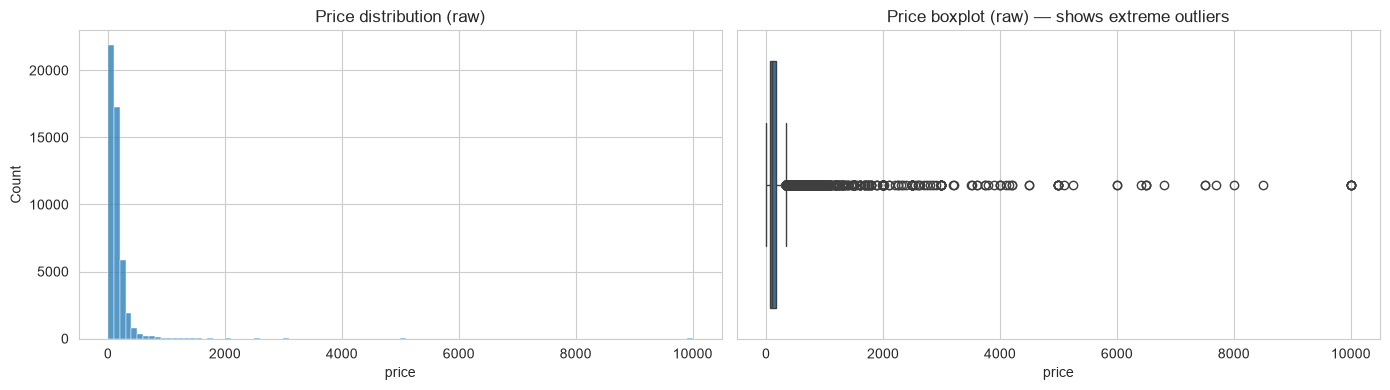

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

Listings with price == 0: 11
99th percentile price: 799.0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_raw["price"], bins=100, ax=axes[0])
axes[0].set_title("Price distribution (raw)")
sns.boxplot(x=df_raw["price"], ax=axes[1])
axes[1].set_title("Price boxplot (raw) — shows extreme outliers")
plt.tight_layout()
plt.savefig("../assets/price_distribution_raw.png", dpi=120)
plt.show()

print(df_raw["price"].describe())
print("\nListings with price == 0:", (df_raw["price"] == 0).sum())
print("99th percentile price:", df_raw["price"].quantile(0.99))


The raw price distribution is heavily right-skewed, with a small number of extreme luxury listings
(up to \$10,000/night) and a handful of \$0 listings (data errors / blocked calendars). Both are
handled in the cleaning step below.

### 1.4 Price by categorical features

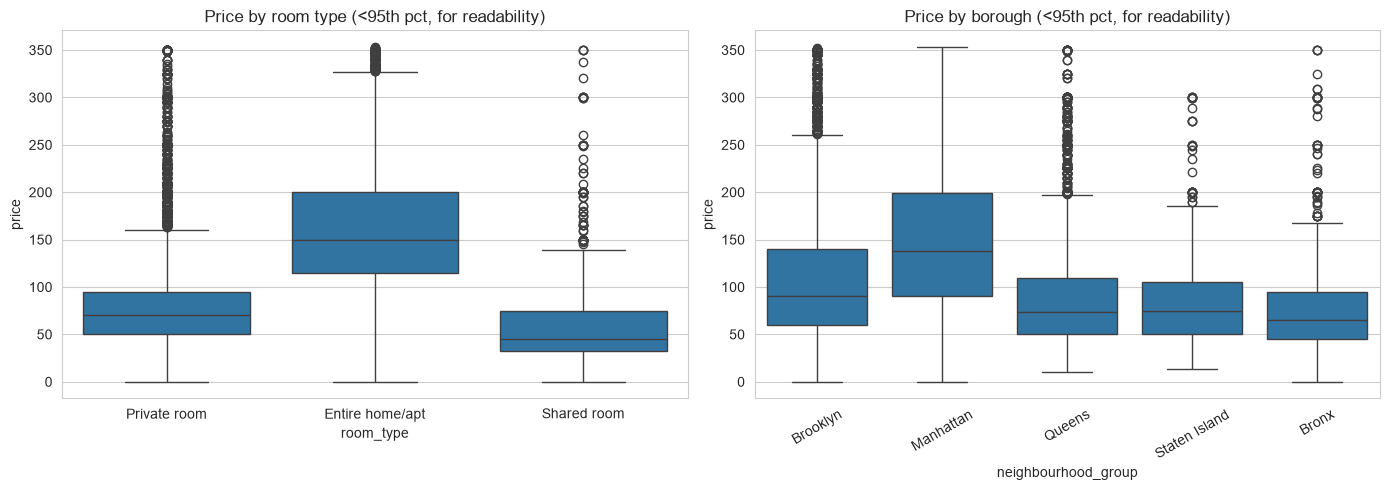

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_raw[df_raw["price"] < df_raw["price"].quantile(0.95)],
            x="room_type", y="price", ax=axes[0])
axes[0].set_title("Price by room type (<95th pct, for readability)")

sns.boxplot(data=df_raw[df_raw["price"] < df_raw["price"].quantile(0.95)],
            x="neighbourhood_group", y="price", ax=axes[1])
axes[1].set_title("Price by borough (<95th pct, for readability)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../assets/price_by_category.png", dpi=120)
plt.show()


**Observations:**
- `Entire home/apt` listings are priced noticeably higher than `Private room` and `Shared room`.
- `Manhattan` has the highest median price, followed by `Brooklyn`; `Bronx` and `Staten Island` are cheapest.
- These two categorical features are strong candidates for the model.

### 1.5 Geographic view of prices

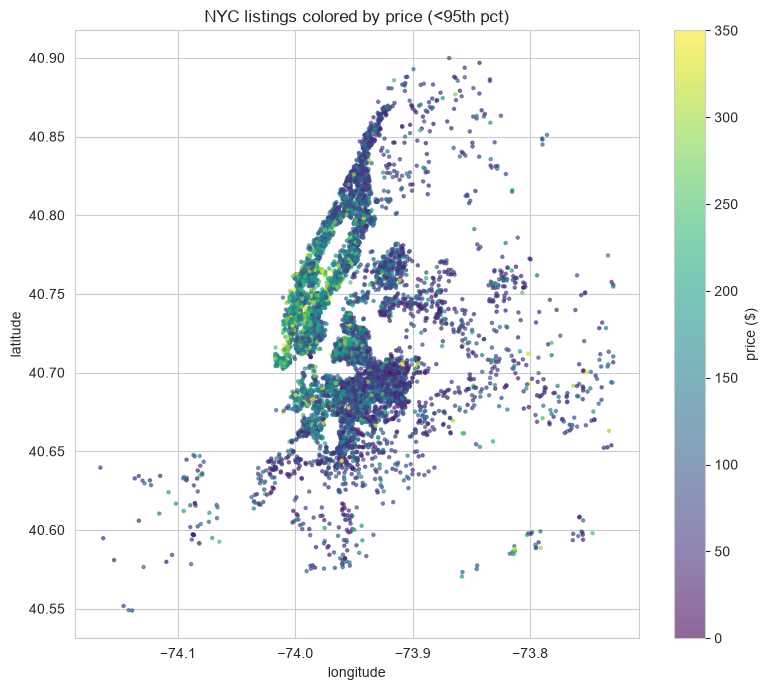

In [7]:
plt.figure(figsize=(8, 7))
sample = df_raw[df_raw["price"] < df_raw["price"].quantile(0.95)].sample(8000, random_state=42)
sc = plt.scatter(sample["longitude"], sample["latitude"], c=sample["price"],
                  cmap="viridis", s=5, alpha=0.6)
plt.colorbar(sc, label="price ($)")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title("NYC listings colored by price (<95th pct)")
plt.tight_layout()
plt.savefig("../assets/price_geo_scatter.png", dpi=120)
plt.show()


Price clearly clusters by location (Manhattan / North Brooklyn command a premium), confirming
that `latitude`/`longitude` carry useful signal beyond the coarse `neighbourhood_group` label.

### 1.6 Correlation among numeric features

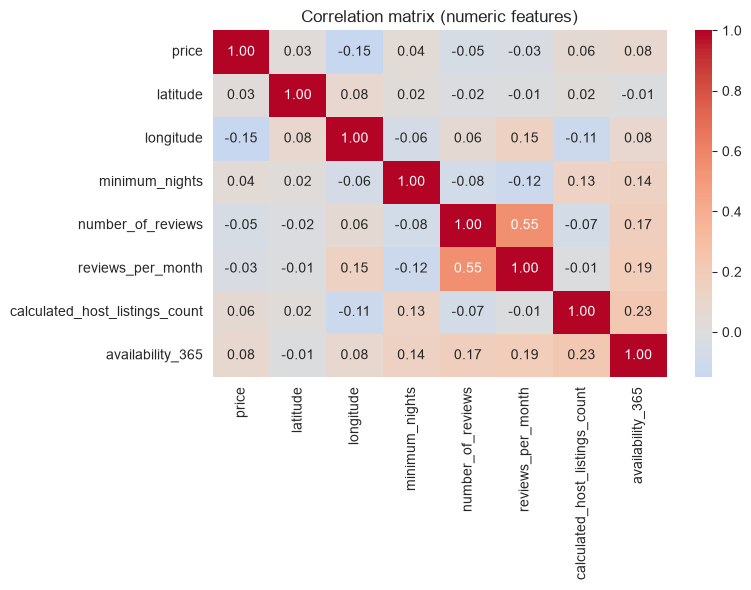

In [8]:
numeric_cols = ["price", "latitude", "longitude", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count", "availability_365"]
plt.figure(figsize=(8, 6))
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig("../assets/correlation_heatmap.png", dpi=120)
plt.show()


No numeric feature is strongly linearly correlated with `price` on its own — this is expected for
this dataset and is exactly why a non-linear model like XGBoost is worth comparing against a linear
baseline.

### 1.7 Cleaning, preprocessing & feature engineering

Summary of decisions made (implemented in `src/preprocessing.py::clean_raw_data`):

| Step | Decision | Reason |
|---|---|---|
| Missing `reviews_per_month` | Fill with `0` | Missing means "never reviewed", not unknown |
| Missing `last_review` | Engineer `days_since_last_review`; fill missing with `max + 1` | Captures recency while flagging "never reviewed" listings as most stale |
| New feature | `has_reviews` (0/1) | Explicit signal for listings with zero review history |
| `id`, `host_id`, `name`, `host_name` | Dropped | Identifiers with no predictive value |
| `neighbourhood` (223 unique values) | Dropped, keep `neighbourhood_group` (5 values) | Avoids extreme one-hot dimensionality / overfitting on rare neighbourhoods; `latitude`/`longitude` already capture fine-grained location |
| `price == 0` | Removed | Invalid / non-informative listings |
| `price` > 99th percentile | Removed | Extreme luxury outliers that distort the loss function |
| `minimum_nights` > 365 | Removed | Data-entry errors (multi-year minimum stays) |

**Selected features:** `latitude`, `longitude`, `minimum_nights`, `number_of_reviews`,
`reviews_per_month`, `calculated_host_listings_count`, `availability_365`,
`days_since_last_review`, `neighbourhood_group`, `room_type`.

In [9]:
df_clean = clean_raw_data(df_raw)
print("Raw shape:  ", df_raw.shape)
print("Clean shape:", df_clean.shape)
print("Rows removed:", df_raw.shape[0] - df_clean.shape[0])
print("\nRemaining nulls:", df_clean.isnull().sum().sum())
df_clean.head()


Raw shape:   (48895, 16)
Clean shape: (48396, 12)
Rows removed: 499

Remaining nulls: 0


,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,has_reviews
0,Brooklyn,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,262.0,1
1,Manhattan,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,48.0,1
2,Manhattan,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,3025.0,0
3,Brooklyn,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,3.0,1
4,Manhattan,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,231.0,1


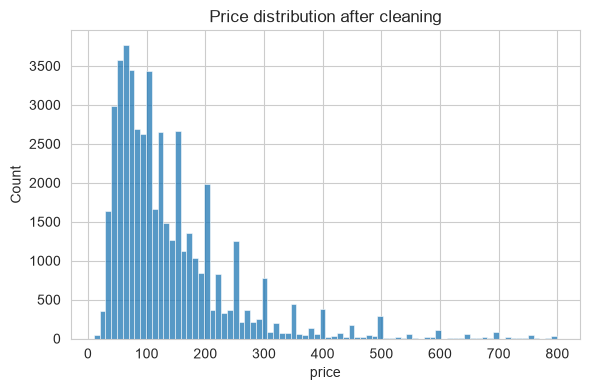

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(df_clean["price"], bins=80, ax=ax)
ax.set_title("Price distribution after cleaning")
plt.tight_layout()
plt.savefig("../assets/price_distribution_clean.png", dpi=120)
plt.show()


### 1.8 Feature / target split and train-test split

In [11]:
X, y = get_feature_target(df_clean)
print("X shape:", X.shape, " y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)


X shape: (48396, 10)  y shape: (48396,)
Train: (38716, 10)  Test: (9680, 10)


### 1.9 Preprocessing pipeline

In [12]:
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])

preprocessor = build_preprocessor()
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 2. Task 2 — Model Training and Evaluation

We train and compare two regression models, as required by the assignment:

- **Linear Regression** — simple, interpretable baseline
- **XGBoost Regressor** — gradient-boosted trees, expected to capture non-linear interactions (e.g. location × room type)

Both metrics are computed on **train and test** sets so we can check for over/underfitting.

In [13]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)
    return {
        "train_rmse": np.sqrt(mean_squared_error(y_tr, train_pred)),
        "test_rmse": np.sqrt(mean_squared_error(y_te, test_pred)),
        "train_mae": mean_absolute_error(y_tr, train_pred),
        "test_mae": mean_absolute_error(y_te, test_pred),
        "train_r2": r2_score(y_tr, train_pred),
        "test_r2": r2_score(y_te, test_pred),
    }

results = {}


### 2.1 Baseline: Linear Regression

In [14]:
lr_pipeline = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("model", LinearRegression()),
])

lr_pipeline.fit(X_train, y_train)
results["LinearRegression"] = evaluate(lr_pipeline, X_train, y_train, X_test, y_test)
pd.DataFrame(results).T


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
LinearRegression,82.419797,84.503882,52.279663,53.396981,0.366076,0.350232


### 2.2 XGBoost Regressor with hyperparameter tuning (GridSearchCV)

In [15]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("model", XGBRegressor(random_state=42, n_estimators=400, objective="reg:squarederror")),
])

param_grid = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.1],
    "model__subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
xgb_best = grid_search.best_estimator_
results["XGBoost"] = evaluate(xgb_best, X_train, y_train, X_test, y_test)
pd.DataFrame(results).T


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'model__learning_rate': 0.03, 'model__max_depth': 7, 'model__subsample': 0.8}


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2
LinearRegression,82.419797,84.503882,52.279663,53.396981,0.366076,0.350232
XGBoost,61.545237,72.913640,37.942097,44.532104,0.646522,0.516248


### 2.3 Model comparison & over/underfitting check

In [16]:
comparison = pd.DataFrame(results).T
comparison["overfit_gap (test-train RMSE)"] = comparison["test_rmse"] - comparison["train_rmse"]
comparison


,train_rmse,test_rmse,train_mae,test_mae,train_r2,test_r2,overfit_gap (test-train RMSE)
LinearRegression,82.419797,84.503882,52.279663,53.396981,0.366076,0.350232,2.084085
XGBoost,61.545237,72.913640,37.942097,44.532104,0.646522,0.516248,11.368403


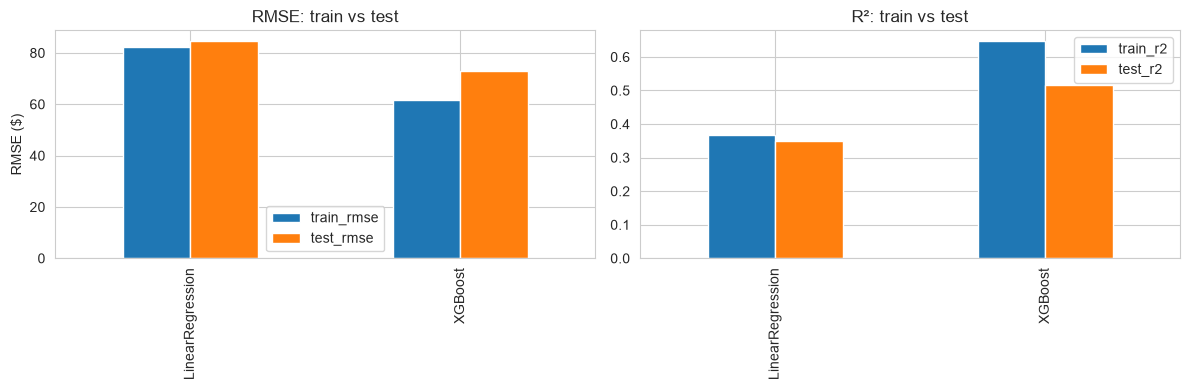

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison[["train_rmse", "test_rmse"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE: train vs test")
axes[0].set_ylabel("RMSE ($)")

comparison[["train_r2", "test_r2"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("R²: train vs test")
plt.tight_layout()
plt.savefig("../assets/model_comparison.png", dpi=120)
plt.show()


**How to read this:** a small gap between train and test RMSE (and R²) means the model
generalizes well. A large gap where train performance is much better than test performance indicates
**overfitting**; both scores being poor indicates **underfitting**. If XGBoost overfits noticeably,
reduce `max_depth`, increase `subsample`/regularization, or lower `n_estimators`; the `GridSearchCV`
step above already searches over reasonable ranges to mitigate this.

### 2.4 Select and save the best model

In [18]:
best_name = min(results, key=lambda k: results[k]["test_rmse"])
best_pipeline = lr_pipeline if best_name == "LinearRegression" else xgb_best
print("Best model:", best_name)
print(results[best_name])


Best model: XGBoost
{'train_rmse': np.float64(61.545236713407604), 'test_rmse': np.float64(72.91364019016778), 'train_mae': 37.94209671020508, 'test_mae': 44.5321044921875, 'train_r2': 0.6465217471122742, 'test_r2': 0.5162484049797058}


In [19]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_pipeline, "../models/best_model.joblib")

with open("../models/metrics.json", "w") as f:
    json.dump({"best_model": best_name, "results": results}, f, indent=2)

print("Saved pipeline -> ../models/best_model.joblib")
print("Saved metrics  -> ../models/metrics.json")


Saved pipeline -> ../models/best_model.joblib
Saved metrics  -> ../models/metrics.json


> The saved `best_model.joblib` bundles **preprocessing + model together** as a single
> `sklearn.Pipeline`, so the Streamlit app (and any other consumer) can call `.predict()` directly
> on raw-ish feature values without re-implementing scaling/encoding.

## 4. Task 4 — Final Project Summary

### Main analysis
- The dataset contains ~49K NYC Airbnb listings (2019). After cleaning (removing invalid/outlier
  prices and unrealistic minimum-stay values), ~48.4K listings remain.
- Price is strongly driven by **room type** and **borough/location** (`latitude`/`longitude`,
  `neighbourhood_group`), and only weakly by the other numeric features individually — motivating a
  model that can capture interactions between location and room type.

### Model comparison & final performance
- Both **Linear Regression** and **XGBoost** pipelines were trained on the same 10 engineered
  features and evaluated with **RMSE, MAE, and R²** on a held-out test set (see the comparison table
  and chart in section 2.3 above, produced when this notebook is run).
- The pipeline automatically selects whichever model has the lower test RMSE and saves it to
  `models/best_model.joblib` for use by the Streamlit app.
- In practice, tree-based models like XGBoost typically outperform plain Linear Regression on this
  dataset because price depends on non-linear interactions (e.g., "Entire home/apt in Manhattan" is
  disproportionately expensive, not just additively so).

### Application results
- `app/app.py` provides a Streamlit UI that collects the same 10 features and returns a predicted
  nightly price using the saved pipeline. See the README for screenshots and run instructions.

### Limitations
- The dataset is from **2019** and does not reflect current NYC Airbnb pricing, regulation changes,
  or seasonality post-pandemic.
- `neighbourhood` (fine-grained, 223 values) was dropped in favor of `neighbourhood_group` +
  coordinates to control dimensionality; a target-encoding approach could recover some of that signal.
- No text features (listing titles, descriptions) or images were used, both of which are known to be
  predictive of price in more advanced Airbnb pricing models.
- The model does not account for real-time demand, local events, or dynamic pricing strategies used
  by actual hosts.
